Data set Loaded Successfully
Rows : 891
Columns : 12

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing values: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0


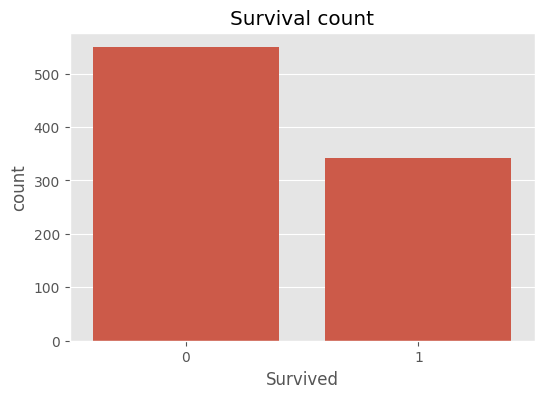

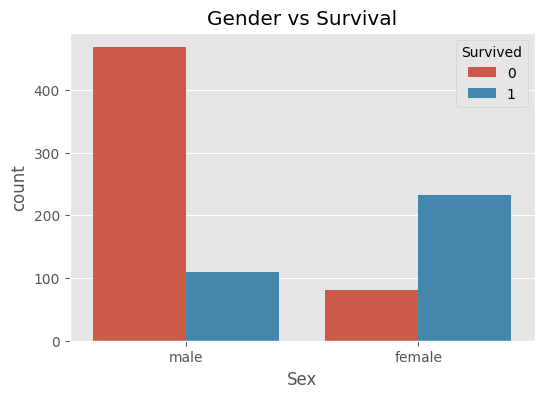

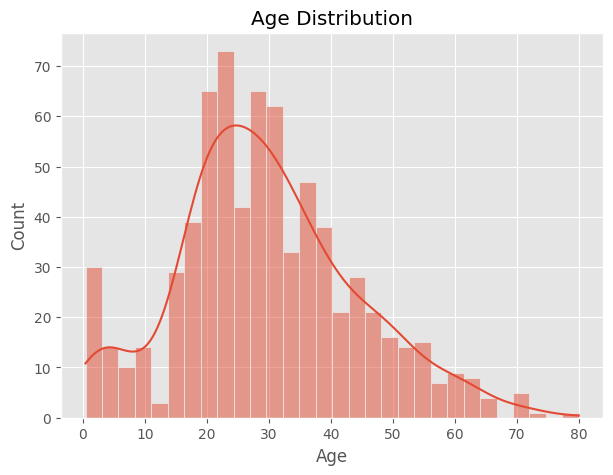

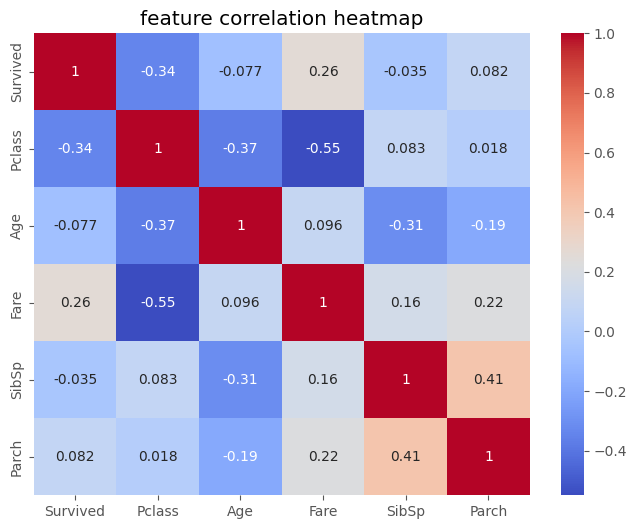


Logistic Regression Result
Accuracy: 0.8379888268156425

classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179


Random forest Result
Accuracy: 0.8212290502793296

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179


XGBOOST RESULT
Accuracy: 0.8324022346368715

ROC AUC Score:
0.8150197628458498

Classification Report:

              precision    recall  f1-score   support

           0       0.84     

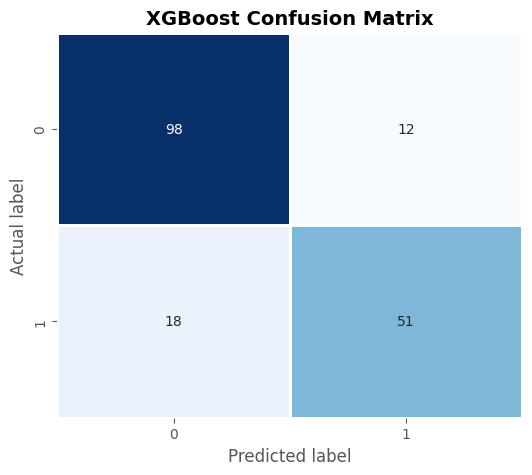

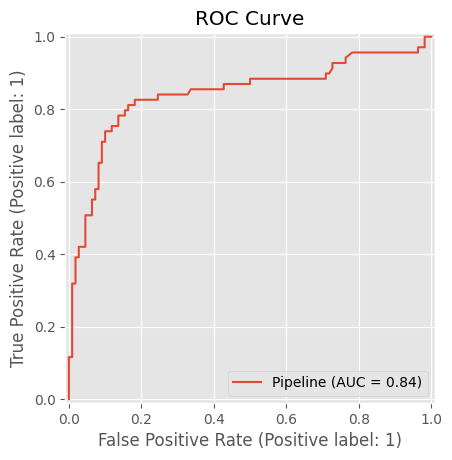


Model comparison
                 Model  Accuracy
0  Logistic Regression  0.837989
2              XGBoost  0.832402
1        Random Forest  0.821229


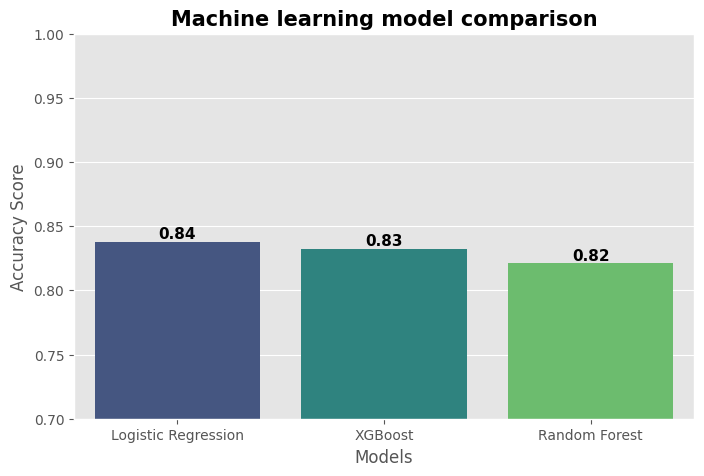


Prediction: Survived


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# LOAD THE DATASET
Data_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(Data_URL)
print("=" * 50)
print("Data set Loaded Successfully")
print("=" * 50)
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# BASIC INFORMATION
print("\nDataset info: ")
print(df.info())

print("\nMissing values: ")
print(df.isnull().sum())

# DATA ANALYSIS
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived" , data=df)
plt.title("Gender vs Survival")
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8,6))
corr_matrix = df[['Survived', 'Pclass', 'Age', 'Fare','SibSp', 'Parch']].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title("feature correlation heatmap")
plt.show()

# Feature Engineering

# Create family size features
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Create ISalone feature
df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)

# Extract title from name
df["Title"] = df["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)

# simplify rare titles
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df["Title"] = df["Title"].replace(rare_titles, 'Rare')
df["Title"] = df["Title"].replace('Mlle', 'Miss')
df["Title"] = df["Title"].replace('Ms', 'Miss')
df["Title"] = df["Title"].replace('Mme', 'Mrs')

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,19,35,60,100],
    labels=["Child", "teen", "Young Adult", "Adult", "Senior"]
)

df["FamilyType"] = np.where(
    df["FamilySize"] > 5,
    "Large",
    np.where(df["FamilySize"] > 1,
             "Small",
             "Alone")
)

# Select Features
features = [
    'Pclass',
    'Sex',
    'Age',
    'Fare',
    'Embarked',
    'FamilySize',
    'IsAlone',
    'Title'
]
X = df[features]
y = df['Survived']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing

numeric_features = ['Age', 'Fare', 'FamilySize']
categorical_features = ['Sex', 'Embarked', 'Title', 'Pclass', 'IsAlone']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Model 1: Logistic Regression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

print("\n" + "="*50)
print("Logistic Regression Result")
print("="*50)

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nclassification Report:\n")
print(classification_report(y_test, lr_pred))

# Model 2: Random Forest

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
        ))
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("\n" + "="*50)
print("Random forest Result")
print("="*50)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

# Model 3: XGBOOST

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42
    ))
])

# Train model
xgb_pipeline.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_pipeline.predict(X_test)

# Result
print("\n" + "="*50)
print("XGBOOST RESULT")
print("="*50)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))


# Confusion matrix

cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    cbar=False
)
plt.title("XGBoost Confusion Matrix",
          fontsize=14,
          fontweight='bold')
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.show()

# ROC curve
RocCurveDisplay.from_estimator(
    xgb_pipeline,
    X_test,
    y_test
)
plt.title("ROC Curve")
plt.show()


# Model Comparison
models = [
    'Logistic Regression',
    'Random Forest',
    'XGBoost'
]
scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]
comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': scores
})

# sort models by accuracy
comparison = comparison.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n" + "="*50)
print("Model comparison")
print("="*50)

print(comparison)

# Visualization
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison,
    palette='viridis'
)

# add accuracy values on bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    "Machine learning model comparison",
    fontsize=15,
    fontweight='bold'
)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0.7, 1.0)
plt.show()


# Sample prediction
sample_passenger = pd.DataFrame({
    'Pclass': [1],
    'Sex': ['female'],
    'Age': [28],
    'Fare': [100],
    'Embarked': ['S'],
    'FamilySize': [1],
    'IsAlone': [1],
    'Title': ['Miss']
})

prediction = xgb_pipeline.predict(sample_passenger)
print("\nPrediction:",
      "Survived" if prediction[0] == 1
      else "Did Not Survive")